## Task 4: Classification Models, Evaluation Metrics & Handling Imbalanced Data

## Step 1: Import Required Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

## Step 2: Load Dataset

In [13]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

## Step 3: Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 4: Feature Scaling

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 5: Train Baseline Classification Model

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

## Step 6: Confusion Matrix & Classification Report

In [17]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

[[41  1]
 [ 1 71]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Step 7: Precision, Recall & F1-Score Interpretation

In [23]:
print("""
True Positives (TP): Correctly predicted Cases
False Positives (FP): Predicted positive but actually negative
False Negatives (FN): Predicted negative but actually positive

Why accuracy alone is insufficient: with imbalanced classes, a model predicting the majority class every time can score high accuracy while missing nearly all cases of the minority class.
""")


True Positives (TP): Correctly predicted Cases
False Positives (FP): Predicted positive but actually negative
False Negatives (FN): Predicted negative but actually positive

Why accuracy alone is insufficient: with imbalanced classes, a model predicting the majority class every time can score high accuracy while missing nearly all cases of the minority class.



## Step 8: ROC Curve & AUC Score

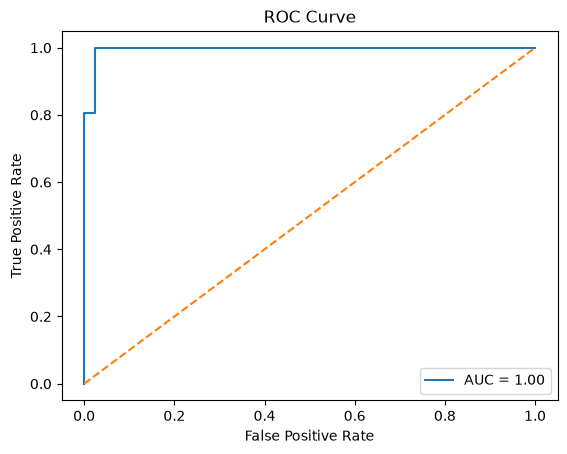

In [19]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step 9: Handle Class Imbalance

In [20]:
model_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## Step 10: Compare with Another Classifier

In [21]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



## Model Comparison Summary

In [22]:
from sklearn.metrics import f1_score, accuracy_score

results = {
    "Model": ["Logistic Regression", "Logistic Regression (Balanced)", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_tree)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_tree)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1 Score
0,Logistic Regression,0.982456,0.986111
1,Logistic Regression (Balanced),0.956140,0.964539
2,Decision Tree,0.912281,0.928571
